<a href="https://colab.research.google.com/github/sawantarya232-blip/Deep-Learning/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import the 'sys' module to interact with the Python interpreter
import sys
# Print the path to the Python executable currently being used
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [ ]:
# Import the 'sys' module
import sys
# Use the command line to install the 'tensorflow' library
# {sys.executable} ensures the correct Python interpreter is used
# -m pip install tells pip to install the package
!{sys.executable} -m pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# Import the TensorFlow library, commonly aliased as 'tf'
import tensorflow as tf
# Print the version of TensorFlow that is currently installed
print(tf.__version__)

2.21.0


In [ ]:
# Import necessary libraries for data manipulation, visualization, and model building
import numpy as np # For numerical operations
import pandas as pd # For data analysis and manipulation
import matplotlib.pyplot as plt # For plotting graphs

from sklearn.preprocessing import MinMaxScaler # For scaling data to a specific range
from sklearn.metrics import mean_squared_error # For evaluating model performance

# Import specific layers for building a Long Short-Term Memory (LSTM) neural network model
from tensorflow.keras.models import Sequential # To create a linear stack of layers
from tensorflow.keras.layers import LSTM, Dense, Dropout # LSTM for sequence processing, Dense for output layer, Dropout for regularization

# Load the training data from a CSV file into a pandas DataFrame
df = pd.read_csv("train.csv")

# Display the first 5 rows of the DataFrame to get an initial look at the data
print(df.head())
# Print the column names of the DataFrame to understand the available features
print(df.columns)

   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0
Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')


In [ ]:
# Convert the 'date' column to datetime objects for easier time-based operations
df["date"] = pd.to_datetime(df["date"])

# Sort the DataFrame by the 'date' column to ensure chronological order
df = df.sort_values("date")

# Group the data by 'date' and sum the 'sales' for each day
# .reset_index() converts the grouped result back into a DataFrame
daily_sales = df.groupby("date")["sales"].sum().reset_index()

# Display the first 5 rows of the daily sales data
print(daily_sales.head())

        date          sales
0 2013-01-01    2511.618999
1 2013-01-02  496092.417944
2 2013-01-03  361461.231124
3 2013-01-04  354459.677093
4 2013-01-05  477350.121229


In [ ]:
# Extract the 'sales' column and reshape it into a 2D array
# This is required by scikit-learn's scaler which expects 2D input
sales = daily_sales["sales"].values.reshape(-1, 1)

# Initialize the MinMaxScaler to scale values between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit the scaler to the sales data and transform the data
# This scales the sales values to a range between 0 and 1
scaled_sales = scaler.fit_transform(sales)

# Print the first 5 scaled sales values
print(scaled_sales[:5])

[[0.        ]
 [0.33793656]
 [0.24575956]
 [0.24096585]
 [0.3251044 ]]


In [ ]:
# Define the number of time steps (lag observations) to use for predicting the next value
time_steps = 30

# Initialize empty lists to store input features (X) and target values (y)
X = []
y = []

# Loop through the scaled sales data to create sequences for the LSTM model
# Each sequence in X will be 'time_steps' long, and y will contain the next value after that sequence
for i in range(time_steps, len(scaled_sales)):
    X.append(scaled_sales[i-time_steps:i, 0]) # Input sequence (past 'time_steps' sales)
    y.append(scaled_sales[i, 0]) # Target value (current sales)

# Convert the lists to NumPy arrays
X = np.array(X)
y = np.array(y)

# Reshape X to be 3-dimensional (samples, time_steps, features)
# LSTMs expect input in this format
X = X.reshape(X.shape[0], X.shape[1], 1)

# Print the shapes of the created input and target arrays
print("X shape:", X.shape) # Should be (number_of_samples, time_steps, 1)
print("y shape:", y.shape) # Should be (number_of_samples,)

X shape: (1654, 30, 1)
y shape: (1654,)


In [ ]:
# Define the proportion of data to be used for training (80% in this case)
train_size = int(len(X) * 0.8)

# Split the input features (X) into training and testing sets
X_train = X[:train_size]
X_test = X[train_size:]

# Split the target values (y) into training and testing sets
y_train = y[:train_size]
y_test = y[train_size:]

# Print the shapes of the training and testing data to verify the split
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1323, 30, 1)
Testing data: (331, 30, 1)


In [ ]:
# Initialize a Sequential model, which is a linear stack of layers
model = Sequential()

# Add the first LSTM layer
# 64 units (neurons) in the LSTM block
# return_sequences=True means it will output a sequence, not just a single value, for the next LSTM layer
# input_shape specifies the shape of the input data (time_steps, number_of_features)
model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

# Add a Dropout layer to prevent overfitting
# 0.2 means 20% of the neurons will be randomly dropped during training
model.add(Dropout(0.2))

# Add a second LSTM layer
# 32 units, and since return_sequences is not True, it defaults to False, outputting a single vector to the next layer
model.add(LSTM(32))

# Add another Dropout layer for regularization
model.add(Dropout(0.2))

# Add a Dense (fully connected) output layer
# 1 unit because we are predicting a single sales value
model.add(Dense(1))

# Compile the model
# optimizer='adam' is an efficient optimization algorithm
# loss='mean_squared_error' is a common loss function for regression tasks
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# Print a summary of the model architecture, including the number of parameters
model.summary()

C:\Users\Asus\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the LSTM model using the training data
# X_train: input features for training
# y_train: target values for training
# epochs=20: the model will iterate over the entire training dataset 20 times
# batch_size=32: the number of samples processed before the model's weights are updated
# validation_split=0.1: 10% of the training data will be used for validation during training
# shuffle=False: data is not shuffled to maintain the time series order
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0191 - val_loss: 0.0099
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0141 - val_loss: 0.0103
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0138 - val_loss: 0.0113
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0137 - val_loss: 0.0109
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0136 - val_loss: 0.0108
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0135 - val_loss: 0.0103
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0129 - val_loss: 0.0101
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0124 - val_loss: 0.0104
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0122 - val_loss: 0.0103
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0123 - val_loss: 0.0113
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0

In [ ]:
# Make predictions on the test set using the trained model
predictions = model.predict(X_test)

# Inverse transform the scaled predictions back to their original sales scale
# This makes the predictions interpretable in terms of actual sales values
predictions = scaler.inverse_transform(predictions)

# Inverse transform the actual test target values back to their original sales scale
actual = scaler.inverse_transform(
    y_test.reshape(-1, 1) # Reshape y_test to be 2D for the inverse transform
)

# Indicate that the prediction process is complete
print("Prediction completed!")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Prediction completed!


In [ ]:
# Calculate the Root Mean Squared Error (RMSE) to evaluate the model's accuracy
# RMSE measures the average magnitude of the errors between predicted and actual values
rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

# Print the calculated RMSE value
print("RMSE:", rmse)

RMSE: 187781.26192729958


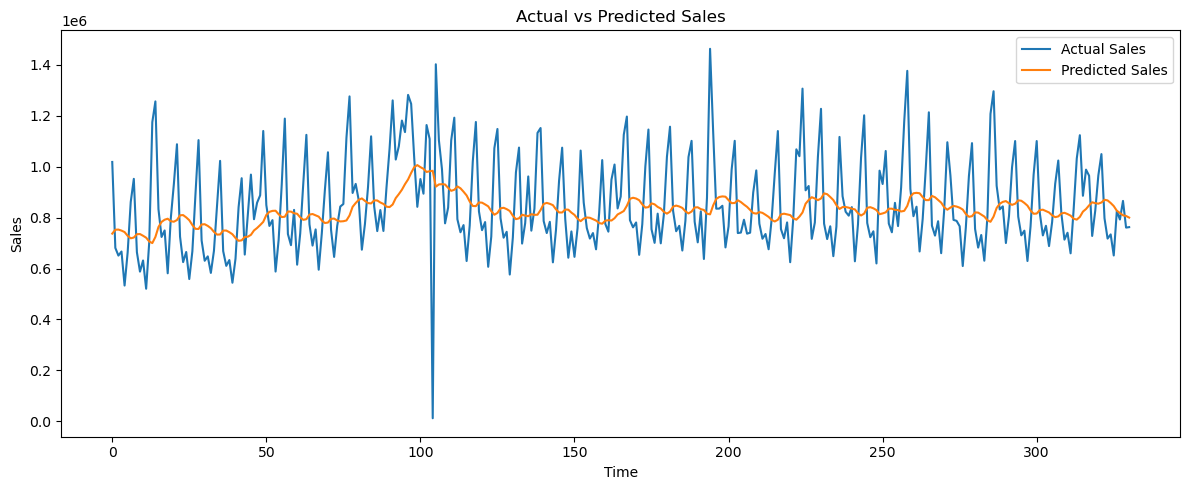

In [ ]:
# Create a new figure for the plot with a specified size
plt.figure(figsize=(12, 5))

# Plot the actual sales values
plt.plot(actual, label="Actual Sales")
# Plot the predicted sales values
plt.plot(predictions, label="Predicted Sales")

# Set the title of the plot
plt.title("Actual vs Predicted Sales")
# Set the label for the x-axis
plt.xlabel("Time")
# Set the label for the y-axis
plt.ylabel("Sales")

# Display the legend to distinguish between actual and predicted sales
plt.legend()
# Adjust plot to ensure everything fits without overlapping
plt.tight_layout()
# Show the plot
plt.show()

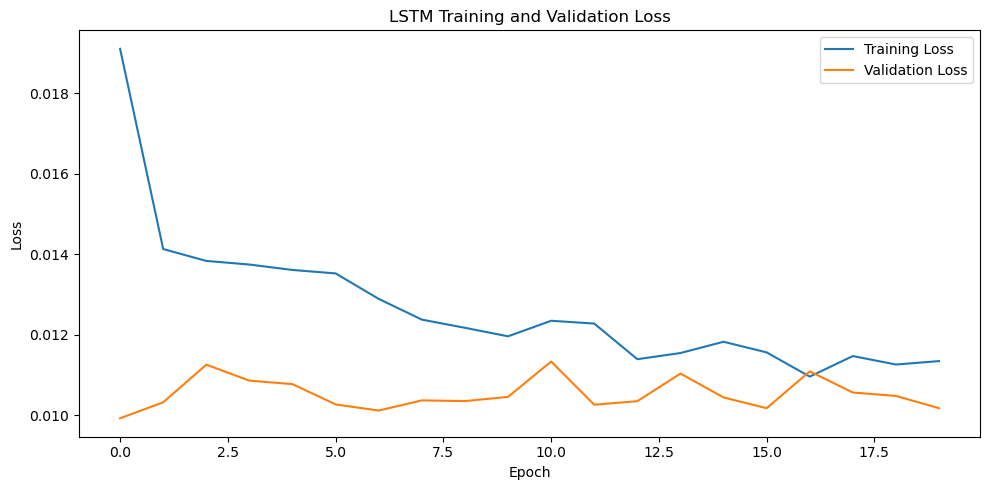

In [ ]:
# Create a new figure for the plot with a specified size
plt.figure(figsize=(10, 5))

# Plot the training loss over epochs
plt.plot(
    history.history["loss"],
    label="Training Loss"
)

# Plot the validation loss over epochs
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

# Set the title of the plot
plt.title("LSTM Training and Validation Loss")
# Set the label for the x-axis
plt.xlabel("Epoch")
# Set the label for the y-axis
plt.ylabel("Loss")

# Display the legend to distinguish between training and validation loss
plt.legend()
# Adjust plot to ensure everything fits without overlapping
plt.tight_layout()
# Show the plot
plt.show()